# 04 · Transfer learning (MobileNetV2)
Usamos una red preentrenada en ImageNet. Dos fases:
1. **Feature extraction:** base congelada, entrenamos solo el cabezal.
2. **Fine-tuning:** descongelamos las capas superiores de la base con un *learning rate* bajo.

In [1]:
# =========================================================
# CONFIGURACIÓN  ·  EDITAR BASE_DIR si hace falta
# =========================================================
from google.colab import drive
drive.mount('/content/drive')

import os

# Carpeta de Drive que CONTIENE "Imagenes OK" y "Imagenes Patologicas".
# Ajustá esta ruta a donde estén tus carpetas.
BASE_DIR = '/content/drive/MyDrive/TP_Final Aprendizaje Automatico'

OK_DIR  = os.path.join(BASE_DIR, 'Imagenes OK')
PAT_DIR = os.path.join(BASE_DIR, 'Imagenes Patologicas')

# Carpeta donde se guardará la partición train/val/test (notebook 02)
DATASET_DIR = os.path.join(BASE_DIR, 'dataset')
# Carpeta donde se guardarán los modelos entrenados
MODELS_DIR  = os.path.join(BASE_DIR, 'modelos')
os.makedirs(MODELS_DIR, exist_ok=True)

# Hiperparámetros globales compartidos
IMG_SIZE = (224, 224)
BATCH    = 32
SEED     = 42

# Las carpetas se ordenan alfabéticamente: 'ok'=0, 'patologica'=1
# => la clase POSITIVA (la que nos importa) es 'patologica' = 1
CLASS_NAMES = ['ok', 'patologica']
print('OK_DIR :', OK_DIR)
print('PAT_DIR:', PAT_DIR)

Mounted at /content/drive
OK_DIR : /content/drive/MyDrive/TP_Final Aprendizaje Automatico/Imagenes OK
PAT_DIR: /content/drive/MyDrive/TP_Final Aprendizaje Automatico/Imagenes Patologicas


## 1. Reconstruir datasets + class_weight

In [2]:
import shutil, tensorflow as tf

# Copiamos la partición de Drive al disco local de Colab (lecturas mucho más rápidas)
LOCAL = '/content/dataset'
if os.path.exists(LOCAL):
    shutil.rmtree(LOCAL)
shutil.copytree(DATASET_DIR, LOCAL)

def make_ds(subset, shuffle):
    return tf.keras.utils.image_dataset_from_directory(
        os.path.join(LOCAL, subset),
        labels='inferred', label_mode='int',
        class_names=CLASS_NAMES,
        color_mode='rgb', image_size=IMG_SIZE,
        batch_size=BATCH, shuffle=shuffle, seed=SEED,
    )

train_ds = make_ds('train', shuffle=True)
val_ds   = make_ds('val',   shuffle=False)
test_ds  = make_ds('test',  shuffle=False)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

Found 308 files belonging to 2 classes.
Found 66 files belonging to 2 classes.
Found 67 files belonging to 2 classes.


In [3]:
import json
with open(os.path.join(DATASET_DIR, 'class_weight.json')) as f:
    class_weight = {int(k): v for k, v in json.load(f).items()}
print('class_weight =', class_weight)

class_weight = {0: 0.9005847953216374, 1: 1.1240875912408759}


## 2. Modelo base + cabezal

In [4]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name='data_augmentation')

base_model = MobileNetV2(input_shape=IMG_SIZE + (3,),
                         include_top=False, weights='imagenet')
base_model.trainable = False          # FASE 1: congelada

inputs  = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = preprocess_input(x)               # escalado específico de MobileNetV2 [-1,1]
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(2, activation='softmax')(x)   # 2 clases: ok / patologica
modelo = models.Model(inputs, outputs, name='transfer_mobilenetv2')
modelo.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "transfer_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 3. Fase 1 — Feature extraction

In [5]:
METRICS = ['accuracy']
modelo.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
               loss='sparse_categorical_crossentropy', metrics=METRICS)

cb1 = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min',
        patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
        patience=4, min_lr=1e-6),
]

hist1 = modelo.fit(train_ds, validation_data=val_ds, epochs=40,
                   class_weight=class_weight, callbacks=cb1)

Epoch 1/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 366ms/step - accuracy: 0.4513 - loss: 1.0016 - val_accuracy: 0.5303 - val_loss: 0.7700 - learning_rate: 0.0010
Epoch 2/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.5844 - loss: 0.7663 - val_accuracy: 0.5758 - val_loss: 0.6818 - learning_rate: 0.0010
Epoch 3/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.5065 - loss: 0.8220 - val_accuracy: 0.6212 - val_loss: 0.6548 - learning_rate: 0.0010
Epoch 4/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.5812 - loss: 0.7230 - val_accuracy: 0.6818 - val_loss: 0.6298 - learning_rate: 0.0010
Epoch 5/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.5974 - loss: 0.7334 - val_accuracy: 0.6818 - val_loss: 0.6186 - learning_rate: 0.0010
Epoch 6/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.6558 - loss: 0.6891 - val_accuracy: 0.6667 - val_loss: 0.6084 - learning_rate: 0.0010
Epoch 7/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.6883 - loss: 0.6293 - val_a

## 4. Fase 2 — Fine-tuning

In [6]:
# Descongelamos la parte superior de la base
base_model.trainable = True
FINE_TUNE_AT = 100                    # capas anteriores quedan congeladas
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

# Recompilar con LR más bajo (clave para no destruir lo aprendido)
modelo.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
               loss='sparse_categorical_crossentropy', metrics=METRICS)

ckpt_path = os.path.join(MODELS_DIR, 'transfer_mobilenetv2.keras')
cb2 = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min',
        patience=10, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(ckpt_path, monitor='val_loss',
        mode='min', save_best_only=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
        patience=4, min_lr=1e-7),
]
hist2 = modelo.fit(train_ds, validation_data=val_ds,
                   epochs=hist1.epoch[-1] + 1 + 30,
                   initial_epoch=hist1.epoch[-1] + 1,
                   class_weight=class_weight, callbacks=cb2)
modelo.save(ckpt_path)
print('Modelo guardado en', ckpt_path)

Epoch 41/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 694ms/step - accuracy: 0.5812 - loss: 0.7252 - val_accuracy: 0.8030 - val_loss: 0.5381 - learning_rate: 1.0000e-05
Epoch 42/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - accuracy: 0.5747 - loss: 0.7458 - val_accuracy: 0.7727 - val_loss: 0.5478 - learning_rate: 1.0000e-05
Epoch 43/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.6396 - loss: 0.6433 - val_accuracy: 0.7424 - val_loss: 0.5561 - learning_rate: 1.0000e-05
Epoch 44/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.6429 - loss: 0.6458 - val_accuracy: 0.7576 - val_loss: 0.5604 - learning_rate: 1.0000e-05
Epoch 45/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.6558 - loss: 0.6139 - val_accuracy: 0.7576 - val_loss: 0.5609 - learning_rate: 1.0000e-05
Epoch 46/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.6558 - loss: 0.5884 - val_accuracy: 0.7576 - val_loss: 0.5588 - learning_rate: 5.0000e-06
Epoch 47/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accur

## 5. Curvas (fase 1 + fase 2 concatenadas)

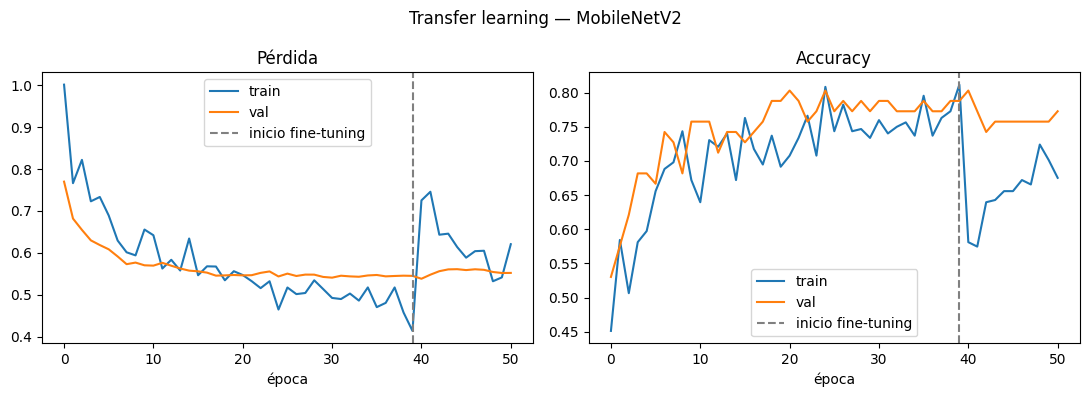

In [7]:
import matplotlib.pyplot as plt

def concat(h1, h2, key):
    return h1.history[key] + h2.history[key]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
corte = len(hist1.history['loss'])
for ax, (m, nombre) in zip(axes, [('loss','Pérdida'),('accuracy','Accuracy')]):
    ax.plot(concat(hist1, hist2, m), label='train')
    ax.plot(concat(hist1, hist2, 'val_'+m), label='val')
    ax.axvline(corte-1, color='gray', ls='--', label='inicio fine-tuning')
    ax.set_title(nombre); ax.set_xlabel('época'); ax.legend()
fig.suptitle('Transfer learning — MobileNetV2'); plt.tight_layout(); plt.show()

## 6. Evaluación rápida sobre test

In [8]:
res = modelo.evaluate(test_ds, return_dict=True)
for k, v in res.items():
    print(f'{k:10s}: {v:.4f}')

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 319ms/step - accuracy: 0.8060 - loss: 0.4797
accuracy  : 0.8060
loss      : 0.4797


Próximo paso → **05_evaluacion_comparacion.ipynb**.